In [1]:
# All imports/set up here

experiment_path = "/scratch/mansisak/llm_optimizer/cloud"

# Understanding the Algorithm optimization landscape

Unlike predominantly text-based tasks, the algorithmic tasks (KernelBench, CloudCast, CantBeLate) have much sparser optimization landscapes. We want to get a sense for how sparse. If the types of failures that happen are repeated over and over.

Things to plot:
- plot the optimization curves for each run? Highlight the best current score over the course of optimzation w/ a faded out score_per_time_point curve in the background
- Semantic diversity of solutions, vs semantic diversity of failed/degenerate cases
- number of degenerate solutions vs. non-degenerate solutions
- varition of score of all solutions, variation in score of best solutions
- num of repreated or extremely similar failure modes.

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

FAILED_SCORE = -100_000.0  # shared sentinel used by cant_be_late.py / cloud_cast.py
MUTATORS = ["kincontext", "DE", "GA", "GEPA"]
SAMPLING_STRATEGIES = ["highest_scoring", "tournament", "wheel", "most_recent", "random"]
TASKS = ["cantbelate", "cloudcast"]


def parse_run_name(name: str) -> dict:
    """Recover sweep parameters baked into a run directory's name.

    Directory names are '_'.join(str(v) for v in cli_args.values()), so we
    match against the known sweep vocabularies instead of relying on a fixed
    positional schema (the arg list has drifted across experiment.py runs).
    """
    padded = f"_{name}_"
    mutator = next((m for m in MUTATORS if f"_{m}_" in padded), None)
    sampling = next((s for s in SAMPLING_STRATEGIES if f"_{s}_" in padded), None)
    task = next((t for t in TASKS if t in name), None)
    pop_match = re.search(r"_(\d+)_lowest_scoring_", name)
    pop_size = int(pop_match.group(1)) if pop_match else None
    return {
        "mutator": mutator,
        "sampling_strategy": sampling,
        "task": task,
        "max_population_size": pop_size,
    }


def load_run(run_dir: Path) -> pd.DataFrame | None:
    """Load every solution ever evaluated in a run into one row each."""
    bank_path = run_dir / "long_running_solution_bank.json"
    if not bank_path.exists():
        return None
    with open(bank_path) as f:
        bank = json.load(f)
    meta = parse_run_name(run_dir.name)
    rows = [
        {
            "run": run_dir.name,
            "solution_id": int(sol_id),
            "solution": entry["solution"],
            "score": entry["score"],
            "val_score": entry.get("val_score"),
            "degenerate": entry["score"] <= FAILED_SCORE + 1e-6,
            **meta,
        }
        for sol_id, entry in bank.items()
    ]
    return pd.DataFrame(rows)


run_dirs = sorted(p for p in Path(experiment_path).iterdir() if p.is_dir())
solutions_df = pd.concat(
    [df for d in run_dirs if (df := load_run(d)) is not None],
    ignore_index=True,
)

print(f"Loaded {len(solutions_df)} solutions from {solutions_df['run'].nunique()} runs")
print(solutions_df.groupby("task")["run"].nunique().rename("num_runs"))
missing_meta = solutions_df[solutions_df[["mutator", "sampling_strategy", "task"]].isna().any(axis=1)]
if len(missing_meta):
    print(f"WARNING: {missing_meta['run'].nunique()} run(s) had unparseable names")


Loaded 9217 solutions from 16 runs
task
cantbelate    16
Name: num_runs, dtype: int64


## Optimization curves per run: best-so-far vs. raw per-iteration score

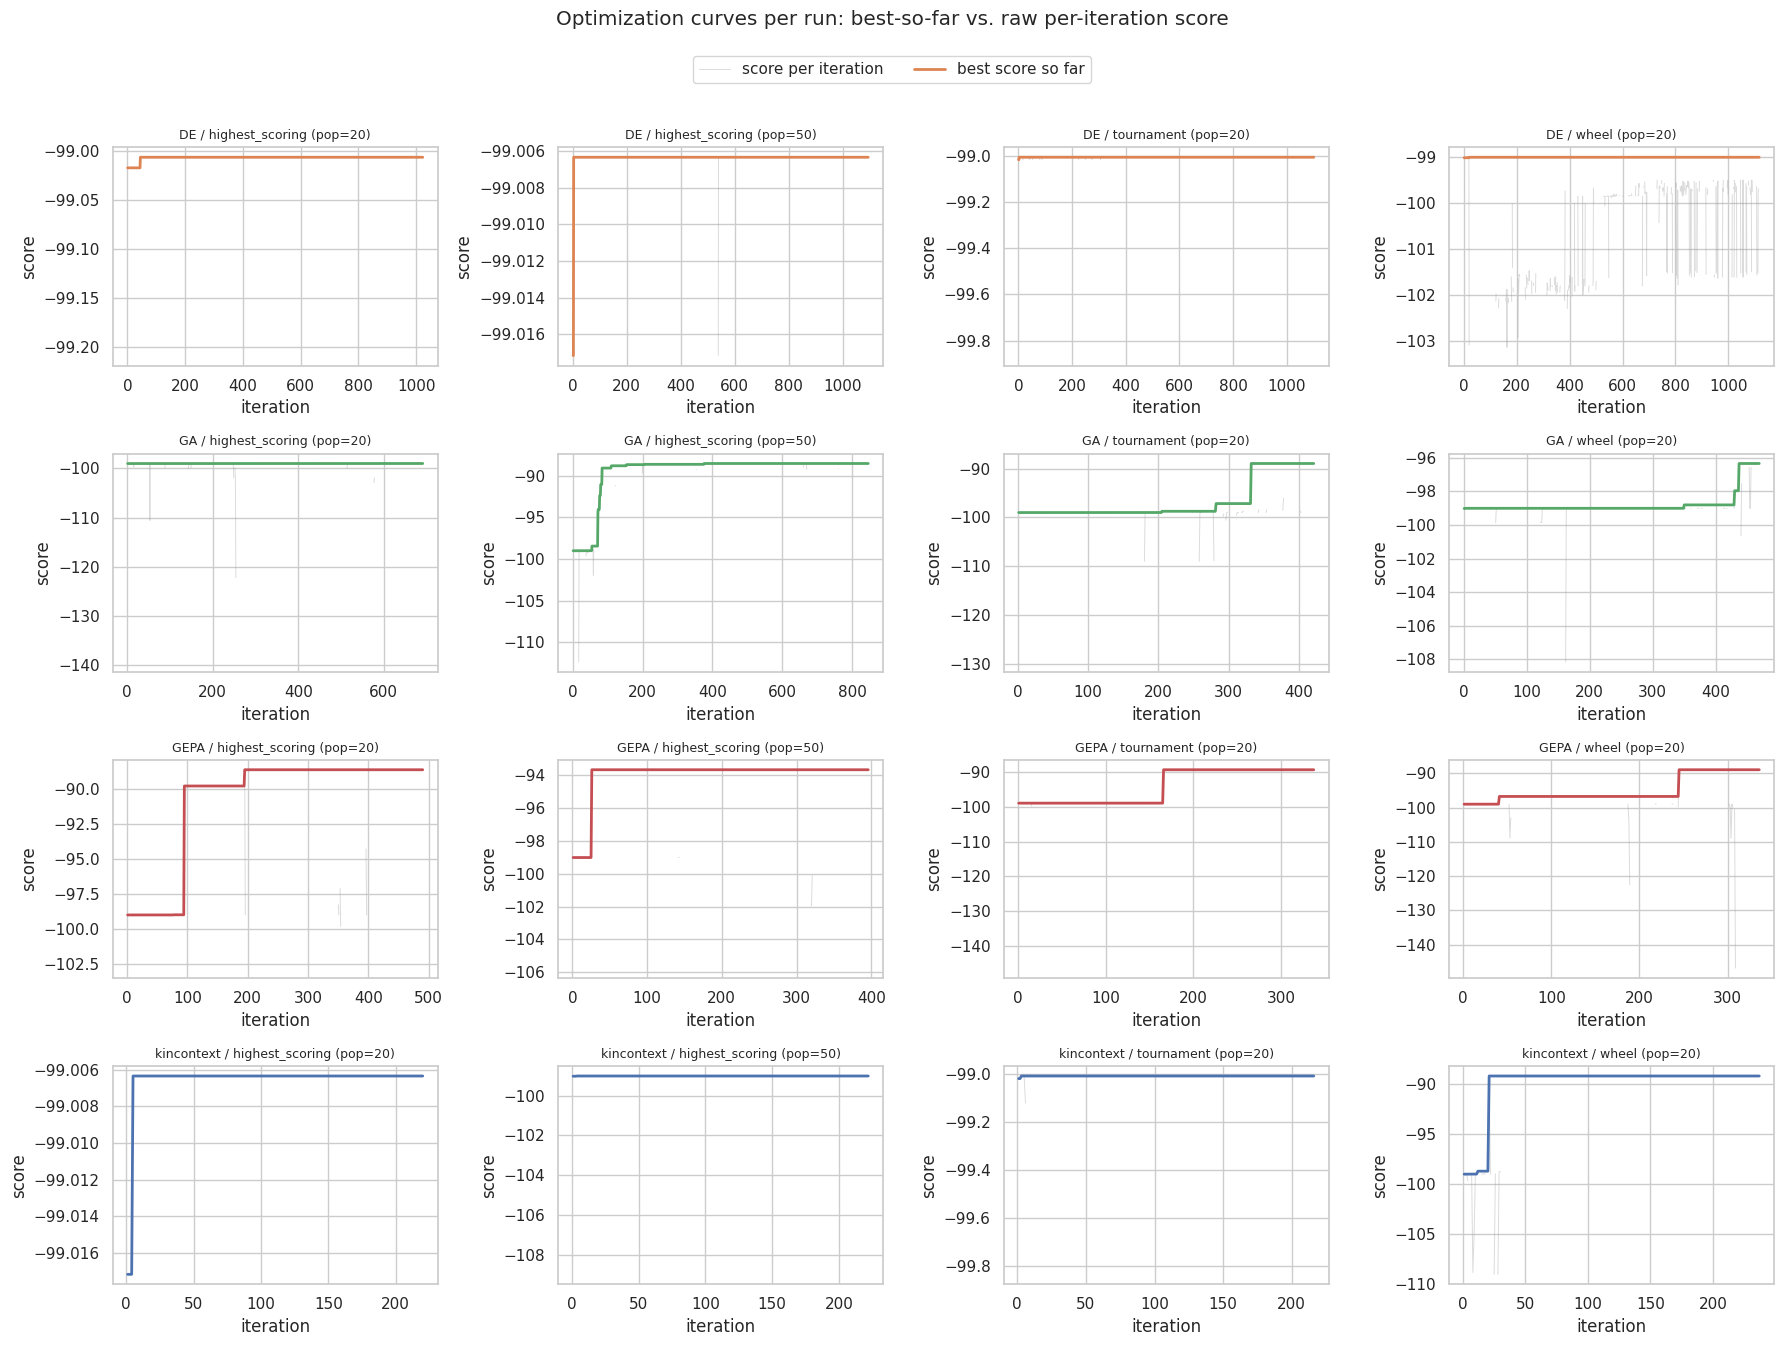

In [3]:
mutator_palette = dict(zip(MUTATORS, sns.color_palette(n_colors=len(MUTATORS))))

run_order = (
    solutions_df[["run", "task", "mutator", "sampling_strategy", "max_population_size"]]
    .drop_duplicates()
    .sort_values(["task", "mutator", "sampling_strategy", "max_population_size"])
)

n_runs = len(run_order)
n_cols = 4
n_rows = int(np.ceil(n_runs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows), squeeze=False)

for ax, (_, meta) in zip(axes.flat, run_order.iterrows()):
    run_df = solutions_df[solutions_df["run"] == meta["run"]].sort_values("solution_id")
    x = run_df["solution_id"].to_numpy()
    y_raw = run_df["score"].where(~run_df["degenerate"])  # NaN out degenerate so the line breaks, not craters
    y_best = run_df["score"].cummax()

    ax.plot(x, y_raw, color="0.6", linewidth=0.7, alpha=0.35, label="score per iteration")
    ax.plot(x, y_best, color=mutator_palette[meta["mutator"]], linewidth=2, label="best score so far")
    ax.set_title(f"{meta['mutator']} / {meta['sampling_strategy']} (pop={meta['max_population_size']})", fontsize=9)
    ax.set_xlabel("iteration")
    ax.set_ylabel("score")

# hide any unused trailing axes when n_runs isn't a multiple of n_cols
for ax in axes.flat[n_runs:]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Optimization curves per run: best-so-far vs. raw per-iteration score", y=1.05)
plt.tight_layout()
plt.show()


## Semantic diversity: degenerate vs. non-degenerate solutions

Loaded 7961 cached code embeddings (flax-sentence-embeddings/st-codesearch-distilroberta-base)


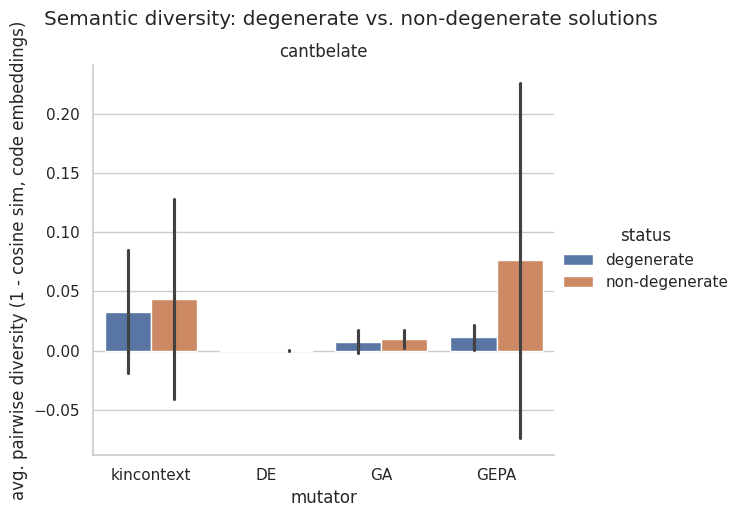

In [4]:
EMBEDDING_MODEL_NAME = "flax-sentence-embeddings/st-codesearch-distilroberta-base"

_emb_texts = pd.read_parquet(Path(experiment_path).parent / "notebooks" / "cloud_solution_texts.parquet")["solution"]
_embeddings = np.load(Path(experiment_path).parent / "notebooks" / "cloud_solution_embeddings.npy")
solution_to_embedding = dict(zip(_emb_texts, _embeddings))
print(f"Loaded {len(solution_to_embedding)} cached code embeddings ({EMBEDDING_MODEL_NAME})")


def avg_pairwise_diversity(texts: list[str], max_docs: int = 400, seed: int = 0) -> float | None:
    """Mean pairwise cosine distance among a set of solutions' code embeddings.

    0 = embeddings identical, 1 = orthogonal. Uses precomputed embeddings from
    a code-specific sentence-embedding model rather than TF-IDF, so near-duplicate
    solutions that differ only in variable names/formatting still register as similar.
    """
    if len(texts) < 2:
        return None
    if len(texts) > max_docs:
        texts = pd.Series(texts).sample(max_docs, random_state=seed).tolist()
    vecs = np.stack([solution_to_embedding[t] for t in texts])
    sim = cosine_similarity(vecs)
    off_diag = sim[~np.eye(sim.shape[0], dtype=bool)]
    return float(1 - off_diag.mean())


diversity_rows = []
for run_name, run_df in solutions_df.groupby("run"):
    meta = run_df.iloc[0][["task", "mutator", "sampling_strategy", "max_population_size"]].to_dict()
    for is_degenerate, label in [(True, "degenerate"), (False, "non-degenerate")]:
        texts = run_df.loc[run_df["degenerate"] == is_degenerate, "solution"].tolist()
        diversity_rows.append({**meta, "run": run_name, "status": label, "diversity": avg_pairwise_diversity(texts)})

diversity_df = pd.DataFrame(diversity_rows).dropna(subset=["diversity"])

g = sns.catplot(
    data=diversity_df,
    x="mutator",
    y="diversity",
    hue="status",
    col="task",
    kind="bar",
    order=[m for m in MUTATORS if m in diversity_df["mutator"].unique()],
    errorbar="sd",
    height=5,
    aspect=1.2,
)
g.set_titles("{col_name}")
g.set_axis_labels("mutator", "avg. pairwise diversity (1 - cosine sim, code embeddings)")
g.figure.suptitle("Semantic diversity: degenerate vs. non-degenerate solutions", y=1.03)
plt.show()


## Degenerate vs. non-degenerate solution counts

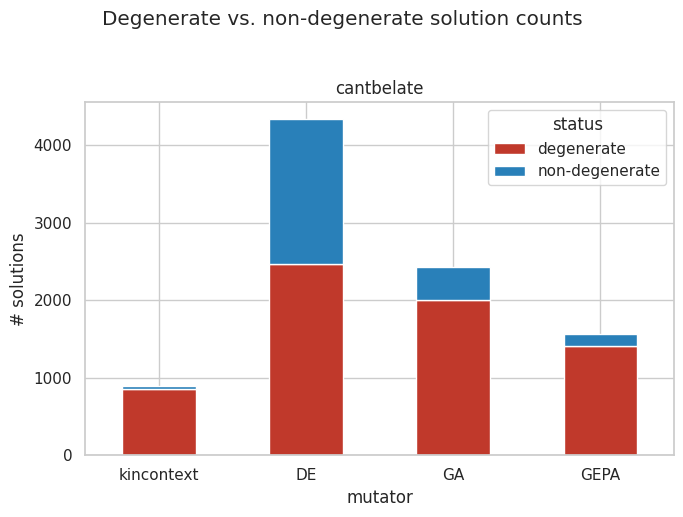

In [5]:
counts = (
    solutions_df
    .assign(status=lambda d: d["degenerate"].map({True: "degenerate", False: "non-degenerate"}))
    .groupby(["task", "mutator", "status"])
    .size()
    .rename("count")
    .reset_index()
)

tasks_present = counts["task"].unique()
fig, axes = plt.subplots(1, len(tasks_present), figsize=(7 * len(tasks_present), 5), squeeze=False)
for ax, task in zip(axes[0], tasks_present):
    sub = counts[counts["task"] == task]
    pivot = sub.pivot(index="mutator", columns="status", values="count").reindex(MUTATORS).dropna(how="all")
    pivot.plot(kind="bar", stacked=True, ax=ax, color={"degenerate": "#c0392b", "non-degenerate": "#2980b9"})
    ax.set_title(task)
    ax.set_ylabel("# solutions")
    ax.set_xlabel("mutator")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Degenerate vs. non-degenerate solution counts", y=1.03)
plt.tight_layout()
plt.show()


## Score variation: full population vs. top solutions

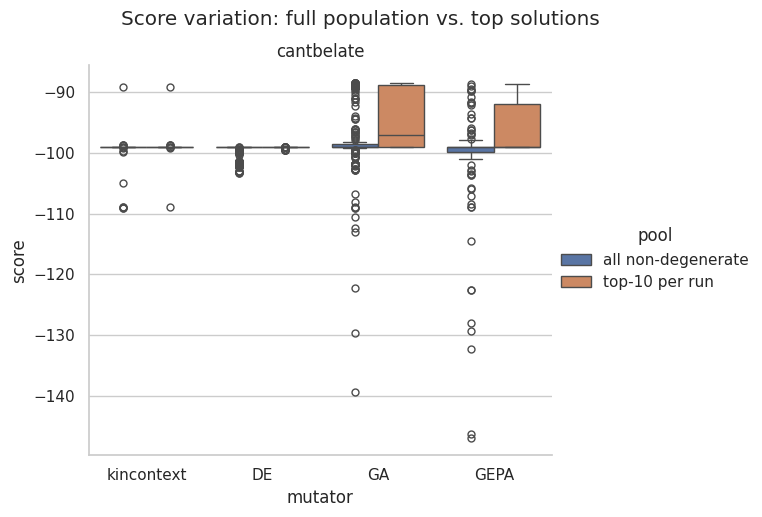

pool                   all non-degenerate  top-10 per run
task       mutator                                       
cantbelate DE                    0.907434        0.188800
           GA                    5.250951        4.342986
           GEPA                  8.001323        3.898721
           kincontext            3.416206        2.560555


In [6]:
TOP_K = 10

non_degenerate = solutions_df[~solutions_df["degenerate"]].copy()
non_degenerate["pool"] = "all non-degenerate"

top_solutions = (
    non_degenerate
    .groupby("run", group_keys=False)[non_degenerate.columns]
    .apply(lambda g: g.nlargest(min(TOP_K, len(g)), "score"))
    .copy()
)
top_solutions["pool"] = f"top-{TOP_K} per run"

combined = pd.concat([non_degenerate, top_solutions], ignore_index=True)

g = sns.catplot(
    data=combined,
    x="mutator",
    y="score",
    hue="pool",
    col="task",
    kind="box",
    order=[m for m in MUTATORS if m in combined["mutator"].unique()],
    height=5,
    aspect=1.2,
    sharey=False,
)
g.set_titles("{col_name}")
g.set_axis_labels("mutator", "score")
g.figure.suptitle("Score variation: full population vs. top solutions", y=1.03)
plt.show()

print(
    combined
    .groupby(["task", "mutator", "pool"])["score"]
    .std()
    .rename("score_std")
    .reset_index()
    .pivot_table(index=["task", "mutator"], columns="pool", values="score_std")
)


## Repeated / near-identical failure modes

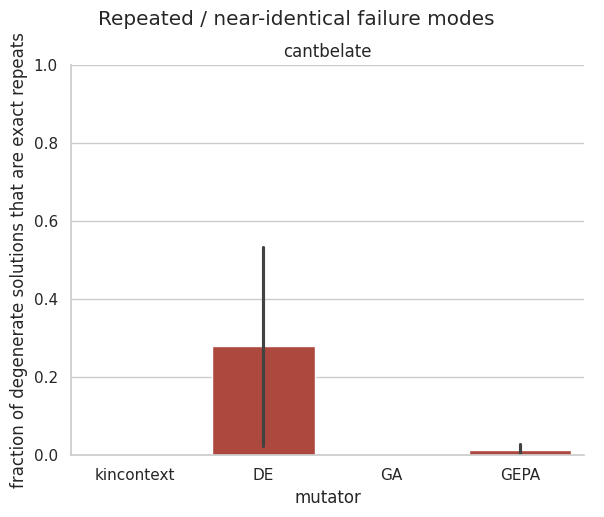

Most repeated degenerate solution signatures (by total occurrence count):
1. count=33  snippet='```python import math from sky_spot.strategies.strategy import Strategy from sky_spot.utils import ClusterType class Evo'
2. count=31  snippet='```python import math from sky_spot.strategies.strategy import Strategy from sky_spot.utils import ClusterType class Opt'
3. count=22  snippet='```python import math from sky_spot.strategies.strategy import Strategy from sky_spot.utils import ClusterType class Opt'
4. count=22  snippet='```python import math from sky_spot.strategies.strategy import Strategy from sky_spot.utils import ClusterType class Evo'
5. count=19  snippet='```python import math from sky_spot.strategies.strategy import Strategy from sky_spot.utils import ClusterType class Opt'


In [7]:
def normalize_code(code: str) -> str:
    return re.sub(r"\s+", " ", code).strip()


degenerate_df = solutions_df[solutions_df["degenerate"]].copy()
degenerate_df["normalized"] = degenerate_df["solution"].map(normalize_code)

signature_counts_per_run = (
    degenerate_df
    .groupby(["task", "mutator", "run", "normalized"])
    .size()
    .rename("count")
    .reset_index()
)
repeat_ratio = (
    signature_counts_per_run
    .groupby(["task", "mutator", "run"])
    .agg(num_degenerate=("count", "sum"), num_unique_signatures=("normalized", "nunique"))
    .reset_index()
)
repeat_ratio["repeat_ratio"] = 1 - repeat_ratio["num_unique_signatures"] / repeat_ratio["num_degenerate"]

g = sns.catplot(
    data=repeat_ratio,
    x="mutator",
    y="repeat_ratio",
    col="task",
    kind="bar",
    order=[m for m in MUTATORS if m in repeat_ratio["mutator"].unique()],
    color="#c0392b",
    height=5,
    aspect=1.2,
)
g.set_titles("{col_name}")
g.set_axis_labels("mutator", "fraction of degenerate solutions that are exact repeats")
g.figure.suptitle("Repeated / near-identical failure modes", y=1.03)
for ax in g.axes.flat:
    ax.set_ylim(0, 1)
plt.show()

top_signatures = (
    degenerate_df.groupby("normalized")["run"].count().sort_values(ascending=False).head(5)
)
print("Most repeated degenerate solution signatures (by total occurrence count):")
for i, (sig, cnt) in enumerate(top_signatures.items(), 1):
    print(f"{i}. count={cnt}  snippet={sig[:120]!r}")
